# Exploration des données de l'API NBA

**Auteur :** Paul · **Lot :** évaluation de l'API `stats.nba.com` · **Étape 1 du projet**

Ce notebook répond à deux questions posées au groupe :

1. **Que nous donne réellement l'API ?** Volume, profondeur temporelle, complétude.
2. **Que voit-on dans ces données ?** Cinq figures commentées, chacune validée par un calcul et non par l'œil.

Le jeu de données est produit par `python -m src.api.fetch_shots`. Chaque ligne est **un tir tenté**,
et la colonne `SHOT_MADE_FLAG` (0 ou 1) est la variable que le projet demande de prédire.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, Arc

# --- Charte graphique du projet -------------------------------------------
# Palette catégorielle validée (séparation suffisante pour les daltonismes
# deutan/protan/tritan). On ne dépasse jamais 3 séries de couleur : au-delà,
# on regroupe en "Autres" ou on fait plusieurs graphiques.
BLEU    = "#2a78d6"
ORANGE  = "#eb6834"
AQUA    = "#1baf7a"
ROUGE   = "#e34948"

# Rampe séquentielle (une seule teinte, clair -> foncé) pour les magnitudes.
RAMPE_BLEUE = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
CMAP_SEQ = mpl.colors.LinearSegmentedColormap.from_list("bleu", RAMPE_BLEUE)

# Rampe divergente (deux teintes opposées + gris neutre au centre) pour les
# écarts par rapport à une référence : au-dessus / en dessous de la moyenne.
CMAP_DIV = mpl.colors.LinearSegmentedColormap.from_list(
    "div", ["#184f95", "#6da7ec", "#f0efec", "#ef8a89", "#c22a29"]
)

ENCRE      = "#11151c"
ENCRE_DOUX = "#59616f"
TRAIT      = "#d6dbe3"

mpl.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": TRAIT,
    "axes.labelcolor": ENCRE_DOUX,
    "axes.titlecolor": ENCRE,
    "axes.titlesize": 12,
    "axes.titleweight": "semibold",
    "axes.titlelocation": "left",
    "axes.titlepad": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": TRAIT,
    "grid.linewidth": 0.6,
    "grid.alpha": 0.7,
    "xtick.color": ENCRE_DOUX,
    "ytick.color": ENCRE_DOUX,
    "text.color": ENCRE,
    "font.size": 10,
    "legend.frameon": False,
})

pd.set_option("display.max_columns", 50)
print("Environnement prêt.")

Environnement prêt.


## 1. Chargement

On lit le fichier produit par l'extraction. Chaque ligne = un tir tenté.

In [2]:
RACINE = Path.cwd()
if not (RACINE / "src" / "api").exists():          # notebook ouvert depuis un sous-dossier
    RACINE = RACINE.parent

CHEMIN = RACINE / "data" / "interim" / "shots_top20.parquet"

if not CHEMIN.exists():
    raise FileNotFoundError(
        f"{CHEMIN} est absent.\n"
        "Lance d'abord l'extraction :\n"
        "  docker compose exec jupyter python -m src.api.fetch_shots"
    )

tirs = pd.read_parquet(CHEMIN)
tirs["GAME_DATE"] = pd.to_datetime(tirs["GAME_DATE"], format="%Y%m%d", errors="coerce")
tirs["SAISON_DEBUT"] = tirs["SEASON"].str[:4].astype(int)

print(f"{len(tirs):,} tirs".replace(",", " "))
print(f"{tirs['PLAYER_NAME'].nunique()} joueurs, {tirs['SEASON'].nunique()} saisons "
      f"({tirs['SEASON'].min()} -> {tirs['SEASON'].max()})")
tirs.head(3)

360 279 tirs
20 joueurs, 30 saisons (1996-97 -> 2025-26)


,GAME_ID,GAME_EVENT_ID,GAME_DATE,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_NAME,PERIOD,MINUTES_REMAINING,SECONDS_REMAINING,ACTION_TYPE,SHOT_TYPE,SHOT_ZONE_BASIC,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,SHOT_DISTANCE,LOC_X,LOC_Y,SHOT_ATTEMPTED_FLAG,SHOT_MADE_FLAG,HTM,VTM,SEASON,SEASON_TYPE,SAISON_DEBUT
0,0020300014,20,2003-10-29,2544,LeBron James,1610612739,Cleveland Cavaliers,1,8,56,Jump Shot,2PT Field Goal,Mid-Range,Right Side(R),8-16 ft.,15.0,158.0,0.0,1,1,SAC,CLE,2003-04,Regular Season,2003
1,0020300014,28,2003-10-29,2544,LeBron James,1610612739,Cleveland Cavaliers,1,7,44,Jump Shot,2PT Field Goal,Mid-Range,Left Side(L),8-16 ft.,13.0,-131.0,2.0,1,1,SAC,CLE,2003-04,Regular Season,2003
2,0020300014,35,2003-10-29,2544,LeBron James,1610612739,Cleveland Cavaliers,1,7,1,Fadeaway Jump Shot,2PT Field Goal,Mid-Range,Right Side(R),16-24 ft.,16.0,163.0,5.0,1,1,SAC,CLE,2003-04,Regular Season,2003


## 2. Volumétrie : que donne l'API, joueur par joueur

**Ce qu'on cherche à savoir :** l'API fournit-elle assez de données pour modéliser chaque joueur
individuellement, ou faudra-t-il un modèle global ? La réponse conditionne toute l'étape 3.

In [3]:
resume = (
    tirs.groupby("PLAYER_NAME")
        .agg(tirs_tentes=("SHOT_MADE_FLAG", "size"),
             tirs_reussis=("SHOT_MADE_FLAG", "sum"),
             saisons=("SEASON", "nunique"),
             matchs=("GAME_ID", "nunique"))
        .assign(reussite=lambda d: d["tirs_reussis"] / d["tirs_tentes"])
        .sort_values("tirs_tentes", ascending=False)
)

print(f"Total : {resume['tirs_tentes'].sum():,} tirs".replace(",", " "))
print(f"Médiane par joueur : {resume['tirs_tentes'].median():,.0f} tirs".replace(",", " "))
resume.style.format({"reussite": "{:.1%}", "tirs_tentes": "{:,.0f}",
                     "tirs_reussis": "{:,.0f}", "matchs": "{:,.0f}"})

Total : 360 279 tirs
Médiane par joueur : 18 286 tirs


,tirs_tentes,tirs_reussis,saisons,matchs,reussite
PLAYER_NAME,,,,,
LeBron James,"31,502","15,961",23,"1,622",50.7%
Kobe Bryant,"26,200","11,719",20,"1,341",44.7%
Dirk Nowitzki,"23,734","11,169",21,"1,521",47.1%
Kevin Durant,"22,375","11,258",18,"1,201",50.3%
Kevin Garnett,"20,407","10,144",20,"1,381",49.7%
Tim Duncan,"20,334","10,285",19,"1,392",50.6%
Allen Iverson,"19,906","8,467",14,914,42.5%
James Harden,"19,733","8,661",17,"1,221",43.9%
Stephen Curry,"19,155","9,022",17,"1,067",47.1%


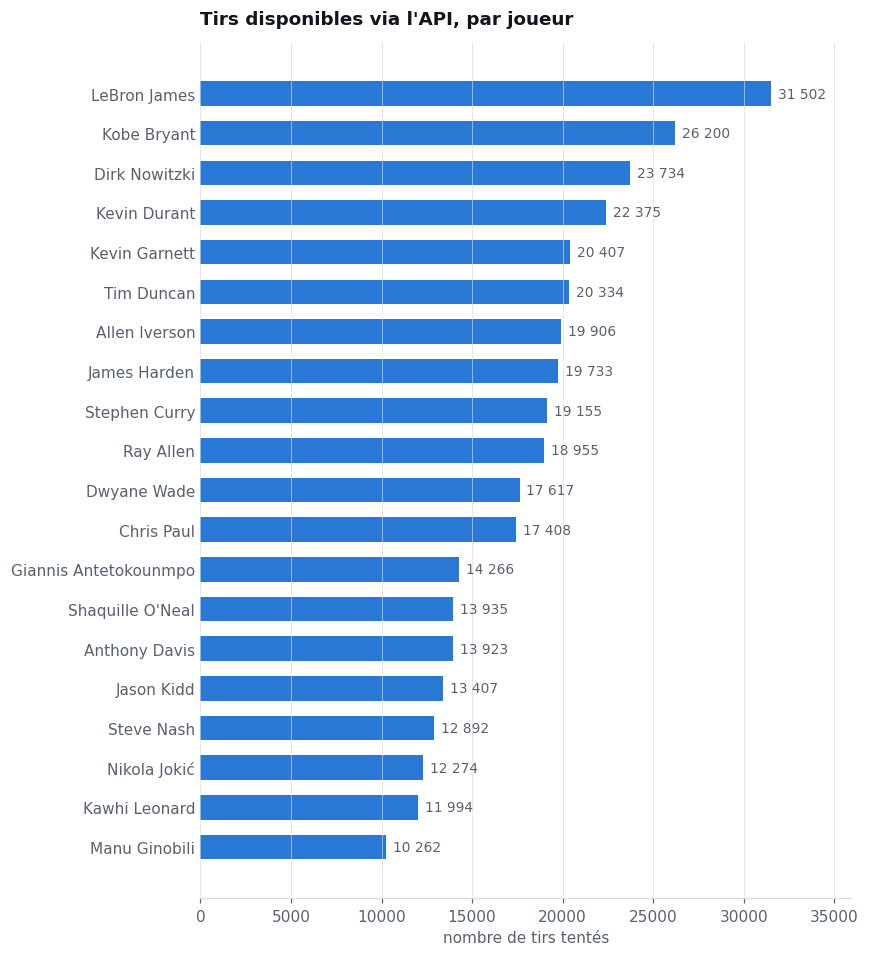

In [4]:
# Forme : barres horizontales. Le travail de la figure est une comparaison de
# magnitudes entre catégories nommées -> les barres horizontales laissent les
# noms lisibles à l'horizontale, contrairement à des barres verticales.
# Une seule série de données -> une seule couleur, pas de légende.
d = resume.sort_values("tirs_tentes")
fig, ax = plt.subplots(figsize=(8, 0.36 * len(d) + 1.6))

ax.barh(d.index, d["tirs_tentes"], color=BLEU, height=0.62)
for nom, v in d["tirs_tentes"].items():
    ax.text(v + d["tirs_tentes"].max() * 0.012, nom, f"{v:,.0f}".replace(",", " "),
            va="center", fontsize=9, color=ENCRE_DOUX)

ax.set_title("Tirs disponibles via l'API, par joueur")
ax.set_xlabel("nombre de tirs tentés")
ax.set_xlim(0, d["tirs_tentes"].max() * 1.14)
ax.grid(axis="y", visible=False)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)
plt.tight_layout()
plt.show()

## 3. Couverture temporelle

**Ce qu'on cherche à savoir :** sur quelles saisons peut-on comparer les joueurs entre eux ?
Kobe Bryant et Nikola Jokić n'ont presque aucune saison commune, toute comparaison directe
de leurs pourcentages mélange deux époques du jeu.

Forme retenue : une carte de chaleur joueur × saison. La grandeur encodée est un volume,
donc **une seule teinte, du clair au foncé**.

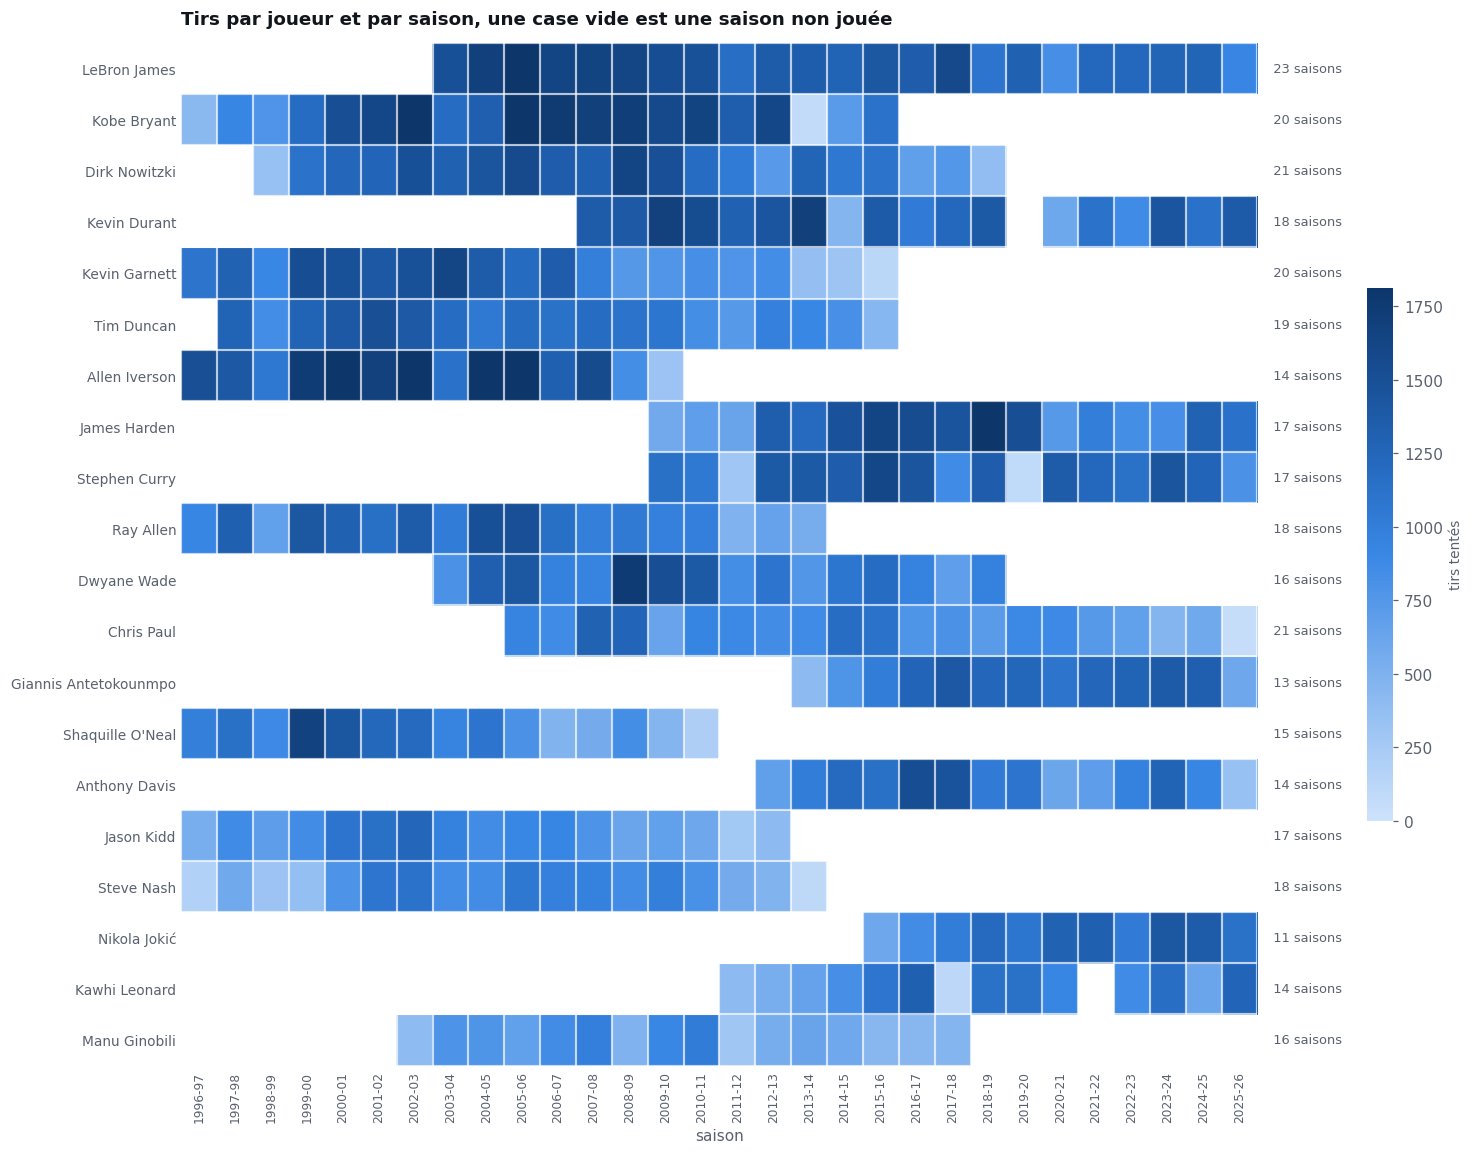

Saisons où au moins 10 des 20 joueurs sont présents : 2002-03 à 2018-19 (17 saisons)
Maximum de joueurs simultanés : 16 en 2009


In [5]:
pivot = (tirs.pivot_table(index="PLAYER_NAME", columns="SAISON_DEBUT",
                          values="SHOT_MADE_FLAG", aggfunc="size")
              .reindex(resume.index))

fig, ax = plt.subplots(figsize=(13.5, 0.4 * len(pivot) + 2.6))
im = ax.imshow(pivot.values, aspect="auto", cmap=CMAP_SEQ,
               vmin=0, vmax=np.nanpercentile(pivot.values, 98))

# Une étiquette par saison, à la verticale : 30 saisons ne tiennent pas
# côte à côte à l'horizontale, elles se chevauchaient.
etiquettes = [f"{a}-{str(a + 1)[-2:]}" for a in pivot.columns]
ax.set_xticks(range(pivot.shape[1]), etiquettes, rotation=90, fontsize=8)
ax.set_yticks(range(len(pivot)), pivot.index, fontsize=9)

# Quadrillage blanc entre les cases : sépare les saisons sans ajouter d'encre.
ax.set_xticks(np.arange(-0.5, pivot.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(pivot), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=1.4)
ax.grid(which="major", visible=False)
ax.tick_params(which="minor", length=0)
ax.tick_params(length=0)
for s in ax.spines.values():
    s.set_visible(False)

# Nombre de saisons couvertes, en bout de ligne : le chiffre exact évite
# d'avoir à compter les cases à l'œil.
for i, nom in enumerate(pivot.index):
    ax.text(pivot.shape[1] - 0.3, i, f"  {int(pivot.loc[nom].notna().sum())} saisons",
            va="center", fontsize=8.5, color=ENCRE_DOUX)

ax.set_title("Tirs par joueur et par saison, une case vide est une saison non jouée")
ax.set_xlabel("saison")

cb = fig.colorbar(im, ax=ax, pad=0.09, fraction=0.022)
cb.set_label("tirs tentés", color=ENCRE_DOUX, fontsize=9)
cb.outline.set_visible(False)
plt.tight_layout()
plt.show()

presence = pivot.notna().sum(axis=0)
plein = presence[presence >= 10]
print(f"Saisons où au moins 10 des 20 joueurs sont présents : "
      f"{plein.index.min()}-{str(plein.index.min() + 1)[-2:]} à "
      f"{plein.index.max()}-{str(plein.index.max() + 1)[-2:]} "
      f"({len(plein)} saisons)")
print(f"Maximum de joueurs simultanés : {presence.max()} en {presence.idxmax()}")


### Commentaire

La figure montre que **le périmètre du sujet n'est jamais complet à un instant donné**. Le
maximum de joueurs simultanément actifs est de **16 sur 20, atteint en 2009-10**. Aux deux
extrémités de la période, ils ne sont plus qu'une poignée.

Les trous à l'intérieur des lignes sont aussi parlants que les bords : Kevin Durant est absent
en 2019-20 après sa rupture du tendon d'Achille, Kawhi Leonard en 2021-22 après sa blessure au
genou. Ces saisons manquantes ne sont pas des défauts de données.

**Validation du constat.** Kobe Bryant a joué de 1996-97 à 2015-16, Nikola Jokić depuis
2015-16. Ils n'ont donc **qu'une seule saison en commun**, et c'était la saison d'adieu de
Kobe, la moins représentative de sa carrière. Comparer leurs taux de réussite bruts, 44,7 %
contre 56,1 %, reviendrait à comparer un arrière extérieur des années 2000 à un pivot des
années 2020 : deux postes, deux époques, deux règles du jeu.

**Conséquence pour la suite.** Toute comparaison directe entre joueurs doit être restreinte à
une fenêtre commune, ou corrigée de l'effet époque. La saison devra figurer comme variable dans
le modèle, et le découpage apprentissage/test tenir compte du temps.


## 4. Réussite et distance

**Ce qu'on cherche à savoir :** la relation la plus forte du jeu de données, et le point de
départ obligé de toute modélisation.

Deux informations doivent être lues ensemble: le taux de réussite et le volume de tirs.
Mais elles n'ont ni la même unité ni la même échelle. On les met donc dans deux graphiques
superposés partageant l'axe des distances, jamais sur deux axes verticaux d'un même
graphique : un double axe permet de faire dire n'importe quoi à deux courbes.

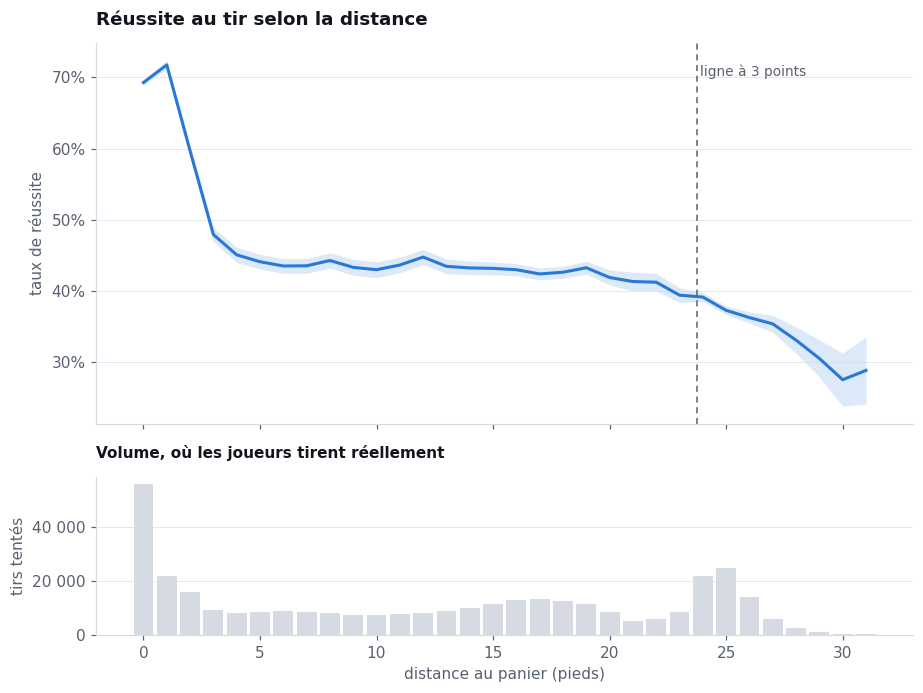

Sous le panier (0-4 ft) : 58.7%
Mi-distance (16-22 ft)  : 42.2%
Au-delà des 3 pts       : 33.5%


In [6]:
PAS = 1  # pied
sous = tirs[tirs["SHOT_DISTANCE"] <= 35].copy()
sous["bin"] = (sous["SHOT_DISTANCE"] // PAS) * PAS

profil = (sous.groupby("bin")
              .agg(reussite=("SHOT_MADE_FLAG", "mean"), n=("SHOT_MADE_FLAG", "size"))
              .query("n >= 200"))

# intervalle de confiance à 95 % sur une proportion (Wald) : sans lui, les
# points construits sur peu de tirs paraissent aussi fiables que les autres.
err = 1.96 * np.sqrt(profil["reussite"] * (1 - profil["reussite"]) / profil["n"])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8.5, 6.4), sharex=True,
                               gridspec_kw={"height_ratios": [2.4, 1]})

ax1.fill_between(profil.index, profil["reussite"] - err, profil["reussite"] + err,
                 color=BLEU, alpha=0.16, linewidth=0)
ax1.plot(profil.index, profil["reussite"], color=BLEU, linewidth=2)
ax1.axvline(23.75, color=ENCRE_DOUX, linewidth=1, linestyle=(0, (4, 3)))
ax1.text(23.9, ax1.get_ylim()[1] * 0.96, "ligne à 3 points", fontsize=9,
         color=ENCRE_DOUX, va="top")
ax1.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0, decimals=0))
ax1.set_ylabel("taux de réussite")
ax1.set_title("Réussite au tir selon la distance")
ax1.grid(axis="x", visible=False)

ax2.bar(profil.index, profil["n"], color=TRAIT, width=PAS * 0.85)
ax2.set_ylabel("tirs tentés")
ax2.set_xlabel("distance au panier (pieds)")
ax2.set_title("Volume, où les joueurs tirent réellement", fontsize=10)
ax2.grid(axis="x", visible=False)
ax2.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: f"{v:,.0f}".replace(",", " ")))

plt.tight_layout()
plt.show()

pres = profil.loc[profil.index <= 4, "reussite"].mean()
mid  = profil.loc[(profil.index >= 16) & (profil.index <= 22), "reussite"].mean()
trois = profil.loc[profil.index >= 24, "reussite"].mean()
print(f"Sous le panier (0-4 ft) : {pres:.1%}")
print(f"Mi-distance (16-22 ft)  : {mid:.1%}")
print(f"Au-delà des 3 pts       : {trois:.1%}")

### Commentaire

La décroissance n'est pas régulière : elle s'effondre dès qu'on quitte la raquette, puis
**se stabilise** entre la mi-distance et le tir à 3 points. C'est le fondement statistique
de l'évolution du jeu depuis 2015, un tir à 3 points rapporte 1,5 fois plus de points pour
un taux de réussite à peine inférieur au tir à mi-distance.

**Validation du constat :** compare l'espérance de points des deux zones, c'est-à-dire
`2 × réussite_mi_distance` contre `3 × réussite_3pts`. Si la seconde est supérieure, le
constat est démontré et plus seulement illustré.

## 5. Carte des tirs

La figure signature du projet. Chaque case du terrain porte l'**écart** entre la réussite
observée et la moyenne du périmètre à distance comparable.

Un écart est une grandeur **bipolaire**, au-dessus, au-dessous, ou nul. Elle appelle donc une
palette divergente : deux teintes opposées et un gris neutre au centre. Une rampe à teinte
unique masquerait le signe.

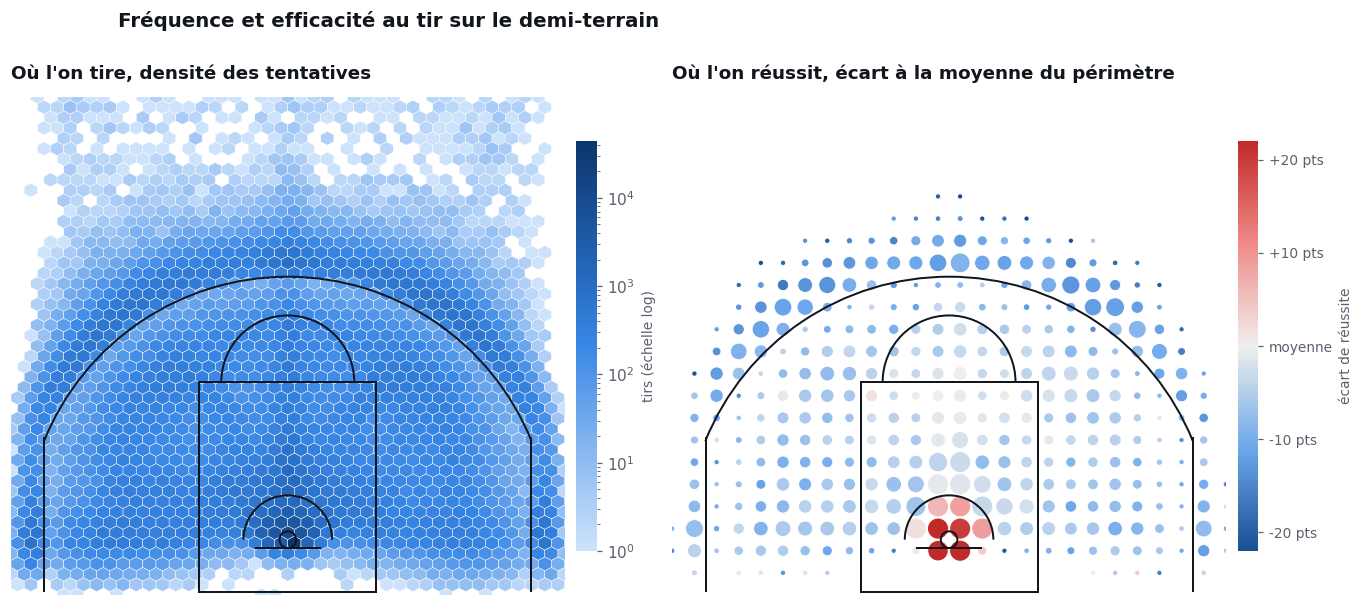

Taille d'un point : nombre de tirs dans la case (minimum 60).


In [7]:
def terrain(ax, couleur=ENCRE, lw=1.3, z=6):
    """Demi-terrain NBA. Unités : dixièmes de pied, origine au centre du panier.

    z (zorder) élevé : les lignes doivent passer AU-DESSUS des marques de
    données, sinon un aplat dense les recouvre et la carte devient illisible.
    """
    for p in (
        Circle((0, 0), 7.5, lw=lw, ec=couleur, fc="none"),                     # arceau
        Rectangle((-30, -7.5), 60, 0, lw=lw, ec=couleur, fc="none"),           # planche
        Rectangle((-80, -47.5), 160, 190, lw=lw, ec=couleur, fc="none"),       # raquette
        Arc((0, 142.5), 120, 120, theta1=0, theta2=180, lw=lw, ec=couleur),    # cercle LF
        Arc((0, 0), 80, 80, theta1=0, theta2=180, lw=lw, ec=couleur),          # zone restreinte
        Rectangle((-220, -47.5), 0, 140, lw=lw, ec=couleur, fc="none"),        # corner gauche
        Rectangle((220, -47.5), 0, 140, lw=lw, ec=couleur, fc="none"),         # corner droit
        Arc((0, 0), 475, 475, theta1=22, theta2=158, lw=lw, ec=couleur),       # arc à 3 pts
    ):
        p.set_zorder(z)
        ax.add_patch(p)
    ax.set_xlim(-250, 250); ax.set_ylim(-50, 400)
    ax.set_aspect("equal"); ax.axis("off")


champ = tirs[(tirs["LOC_Y"].between(-50, 400)) & (tirs["LOC_X"].between(-250, 250))]

TAILLE = 20  # côté d'une case, en dixièmes de pied
gx = (champ["LOC_X"] // TAILLE) * TAILLE
gy = (champ["LOC_Y"] // TAILLE) * TAILLE
cases = (champ.assign(gx=gx, gy=gy)
              .groupby(["gx", "gy"])
              .agg(reussite=("SHOT_MADE_FLAG", "mean"), n=("SHOT_MADE_FLAG", "size"))
              .query("n >= 60")
              .reset_index())
cases["ecart"] = cases["reussite"] - champ["SHOT_MADE_FLAG"].mean()

fig, (axg, axd) = plt.subplots(1, 2, figsize=(12.5, 6))

# Gauche : où l'on tire (volume) -> magnitude -> rampe à teinte unique
terrain(axg)
hb = axg.hexbin(champ["LOC_X"], champ["LOC_Y"], gridsize=42, cmap=CMAP_SEQ,
                bins="log", mincnt=1, extent=(-250, 250, -50, 400),
                edgecolors="white", linewidths=0.3, zorder=2)
axg.set_title("Où l'on tire, densité des tentatives")
cb = fig.colorbar(hb, ax=axg, fraction=0.035, pad=0.02)
cb.set_label("tirs (échelle log)", color=ENCRE_DOUX, fontsize=9)
cb.outline.set_visible(False)

# Droite : où l'on réussit (écart à la moyenne) -> polarité -> palette divergente
terrain(axd)
sc = axd.scatter(cases["gx"] + TAILLE / 2, cases["gy"] + TAILLE / 2,
                 c=cases["ecart"], s=np.clip(cases["n"] / 14, 12, 190),
                 cmap=CMAP_DIV, vmin=-0.22, vmax=0.22,
                 edgecolors="white", linewidths=0.6, zorder=2)
axd.set_title("Où l'on réussit, écart à la moyenne du périmètre")
cb = fig.colorbar(sc, ax=axd, fraction=0.035, pad=0.02)
cb.set_label("écart de réussite", color=ENCRE_DOUX, fontsize=9)
cb.set_ticks([-0.2, -0.1, 0, 0.1, 0.2])
cb.ax.set_yticklabels(["-20 pts", "-10 pts", "moyenne", "+10 pts", "+20 pts"], fontsize=9)
cb.outline.set_visible(False)

fig.suptitle("Fréquence et efficacité au tir sur le demi-terrain", x=0.09, ha="left",
             fontsize=13, fontweight="semibold", color=ENCRE)
plt.tight_layout()
plt.show()

print("Taille d'un point : nombre de tirs dans la case (minimum 60).")


| Zone | Part des tirs | Réussite | Espérance de points |
|---|---|---|---|
| Restricted Area | 28,6 % | 66,4 % | **1,328** |
| Left Corner 3 | 1,7 % | 40,8 % | **1,224** |
| Right Corner 3 | 1,5 % | 39,7 % | **1,190** |
| Above the Break 3 | 20,0 % | 36,7 % | **1,101** |
| In The Paint (Non-RA) | 16,7 % | 44,7 % | 0,894 |
| Mid-Range | 31,3 % | 42,4 % | **0,850** |
| Backcourt | 0,2 % | 3,9 % | 0,117 |



## 5 bis. Comment les emplacements de tir ont évolué

Le même demi-terrain, répété par période. La géométrie, l'échelle de couleur et la palette
sont identiques d'une case à l'autre : c'est la condition pour que la comparaison soit
honnête. Chaque case montre la **part** des tirs de sa période, pas leur nombre, sinon les
périodes les mieux fournies écraseraient les autres.

Cette figure raconte deux choses à la fois, et il faut savoir les distinguer.


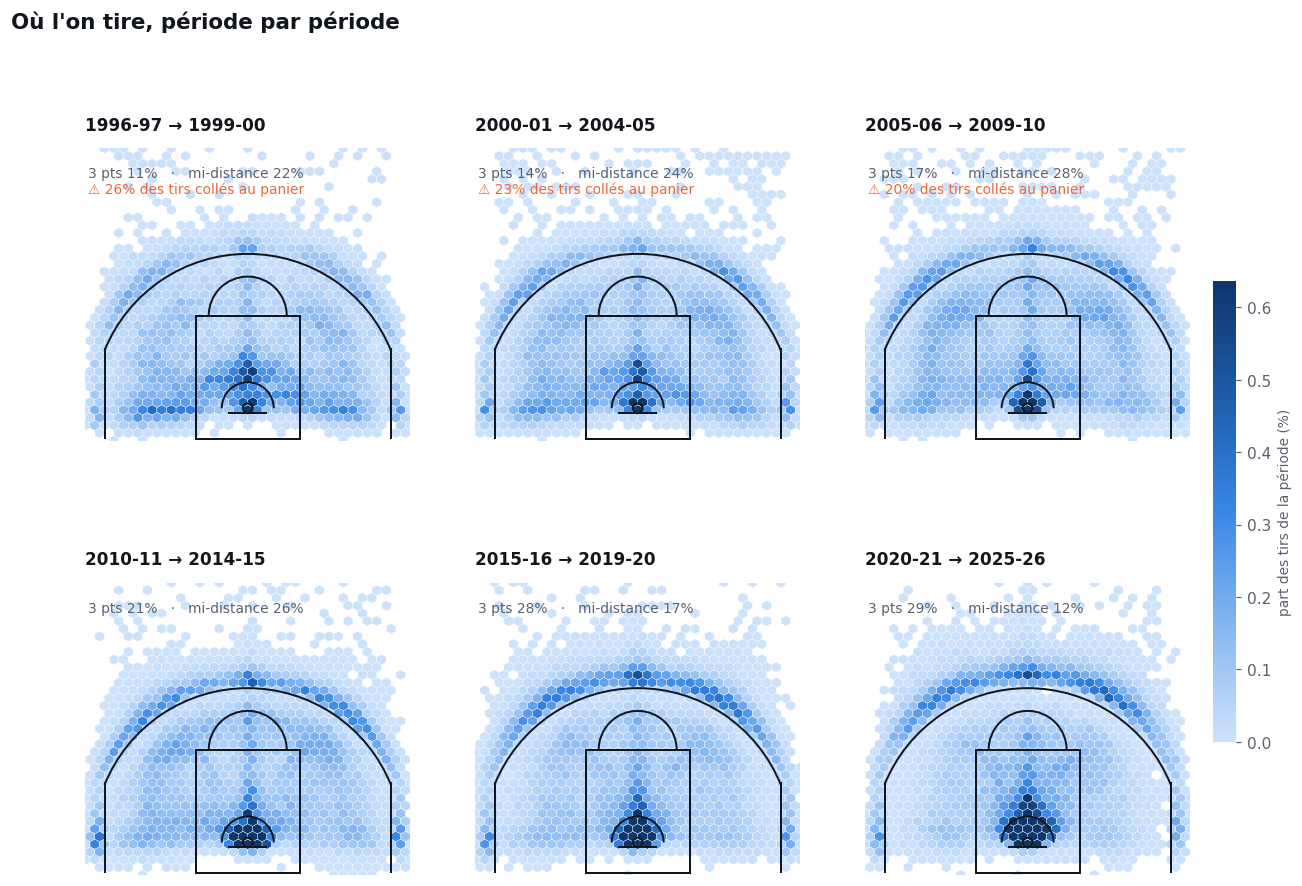

In [12]:
# Petits multiples : un même demi-terrain répété par période.
PERIODES = [
    (1996, 1999, "1996-97 → 1999-00"),
    (2000, 2004, "2000-01 → 2004-05"),
    (2005, 2009, "2005-06 → 2009-10"),
    (2010, 2014, "2010-11 → 2014-15"),
    (2015, 2019, "2015-16 → 2019-20"),
    (2020, 2025, "2020-21 → 2025-26"),
]

champ = tirs[(tirs["LOC_Y"].between(-50, 400)) & (tirs["LOC_X"].between(-250, 250))].copy()

fig, axes = plt.subplots(2, 3, figsize=(13.5, 9.4))
mailles = []
for (a, b, _), ax in zip(PERIODES, axes.ravel()):
    sub = champ[champ["SAISON_DEBUT"].between(a, b)]
    poids = np.full(len(sub), 100 / len(sub))          # -> part en %
    mailles.append(ax.hexbin(sub["LOC_X"], sub["LOC_Y"], C=poids,
                             reduce_C_function=np.sum, gridsize=34, mincnt=1,
                             extent=(-250, 250, -50, 400), cmap=CMAP_SEQ,
                             edgecolors="white", linewidths=0.25, zorder=2))

# Échelle de couleur COMMUNE : sans elle, chaque case aurait sa propre échelle
# et la comparaison entre périodes serait fausse.
vmax = np.percentile(np.concatenate([np.ma.compressed(m.get_array()) for m in mailles]), 99.2)
for m in mailles:
    m.set_clim(0, vmax)

for (a, b, titre), ax in zip(PERIODES, axes.ravel()):
    sub = champ[champ["SAISON_DEBUT"].between(a, b)]
    terrain(ax)
    ax.set_title(titre, fontsize=11)
    ax.text(-245, 372,
            f"3 pts {(sub['SHOT_DISTANCE'] >= 23.75).mean():.0%}"
            f"   ·   mi-distance {sub['SHOT_DISTANCE'].between(16, 23.74).mean():.0%}",
            fontsize=9, color=ENCRE_DOUX, va="top")
    if a < 2010:
        colle = ((sub["LOC_X"] == 0) & (sub["LOC_Y"] == 0)).mean()
        ax.text(-245, 348, f"⚠ {colle:.0%} des tirs collés au panier",
                fontsize=9, color=ORANGE, va="top")

fig.suptitle("Où l'on tire, période par période", x=0.075, ha="left",
             fontsize=14, fontweight="semibold", color=ENCRE)
cb = fig.colorbar(mailles[0], ax=axes, fraction=0.02, pad=0.02)
cb.set_label("part des tirs de la période (%)", color=ENCRE_DOUX, fontsize=9)
cb.outline.set_visible(False)
plt.show()


### Commentaire

**Ce qui est réel : la révolution du tir à 3 points.** L'arc s'allume progressivement d'une
case à l'autre, 11 % des tirs sur la première période, 29 % sur la dernière. Les deux corners
apparaissent nettement à partir de 2010-11 : ce sont les points du terrain où la ligne est la
plus proche, donc les tirs à 3 points les plus rentables. Symétriquement, la mi-distance
s'éteint : 22 % puis 12 %. C'est exactement ce que le calcul d'espérance de points prédisait.

**Ce qui est un artefact : la tache sous le panier avant 2010-11.** Ce n'est pas un fait de
jeu. Jusqu'en 2009-10, la NBA ne relevait pas la position réelle des tirs près du cercle : elle
les ramenait tous aux coordonnées exactes du panier. D'où ce point unique très sombre entouré
de vide, alors qu'à partir de 2010-11 on voit un cône de tirs naturellement étalé.

Cela concerne **39 057 tirs, soit 22 % de toutes les données antérieures à 2010**, tous en zone
restreinte. Le phénomène réapparaît partiellement à partir de 2020-21, autour de 8 %.

**Conséquence pour la suite du projet.** Les coordonnées d'avant 2010-11 ne permettent pas une
analyse spatiale fine. Deux options : restreindre le périmètre à partir de 2010-11, ce qui
coïncide avec le début des données de tracking, ou conserver toute la profondeur en renonçant
aux coordonnées et en ne travaillant que sur les zones. À trancher en réunion.

Une seconde rupture, invisible sur cette figure mais du même ordre, touche `ACTION_TYPE` :
10 libellés de geste en 1996-97, 29 à partir de 2000-01, 49 à partir de 2007-08. Le
`Step Back Jump shot` et le `Pullup Jump shot`, aujourd'hui parmi les plus fréquents, sont des
créations du système de notation, pas des gestes nouveaux. Or `ACTION_TYPE` est notre variable
la plus prédictive : un découpage train/test chronologique sur toute la profondeur ferait
travailler le modèle sur deux vocabulaires différents.


## 6. Le type de geste

**Ce qu'on cherche à savoir :** quelle variable, parmi celles que l'API fournit, sépare le mieux
les tirs réussis des tirs manqués.

`ACTION_TYPE` décrit le geste : dunk, layup en pénétration, step-back à 3 points, fadeaway…
C'est la variable la plus riche du jeu de données, et la plus sous-utilisée.

On se limite aux gestes ayant un volume suffisant : classer des modalités vues 30 fois produit
un classement qui n'est que du bruit.

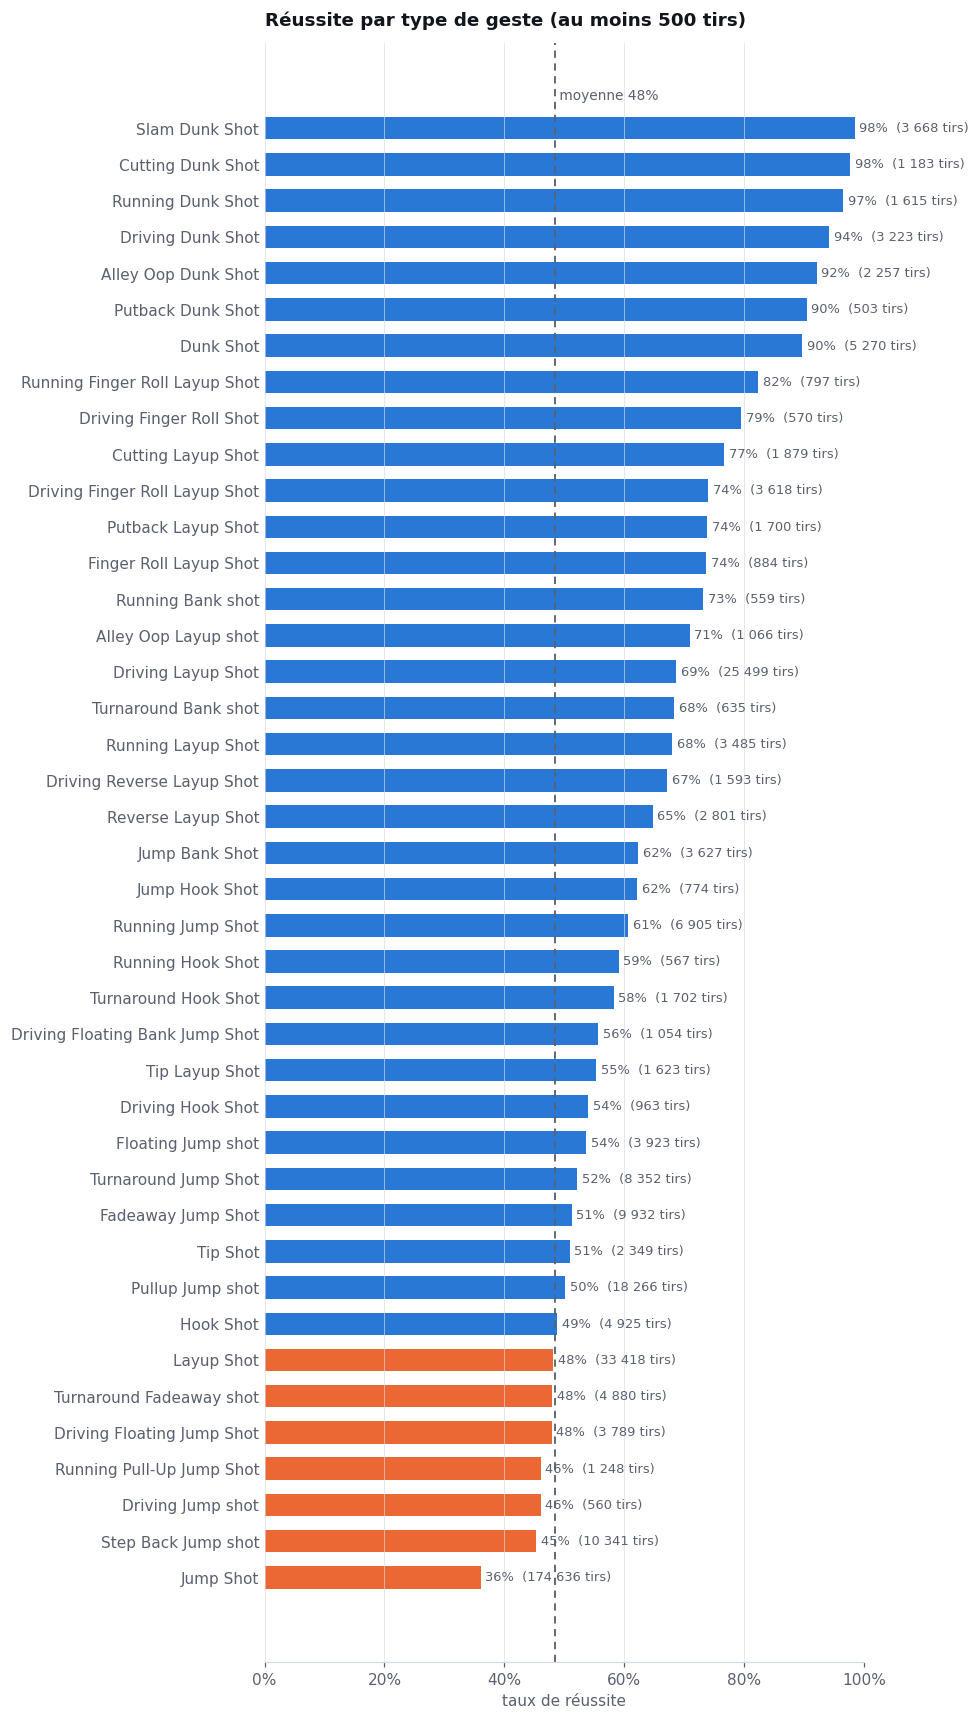

70 gestes distincts au total, dont 41 au-dessus de 500 tirs.
Amplitude entre le meilleur et le pire geste : 62% de réussite.


In [9]:
MIN_N = 500
gestes = (tirs.groupby("ACTION_TYPE")
              .agg(reussite=("SHOT_MADE_FLAG", "mean"), n=("SHOT_MADE_FLAG", "size"))
              .query("n >= @MIN_N")
              .sort_values("reussite"))

moyenne = tirs["SHOT_MADE_FLAG"].mean()
# Deux couleurs seulement, et elles encodent une information : au-dessus ou en
# dessous de la moyenne générale. Pas de dégradé décoratif.
couleurs = np.where(gestes["reussite"] >= moyenne, BLEU, ORANGE)

fig, ax = plt.subplots(figsize=(9, 0.34 * len(gestes) + 1.8))
ax.barh(gestes.index, gestes["reussite"], color=couleurs, height=0.62)
ax.axvline(moyenne, color=ENCRE_DOUX, linewidth=1.2, linestyle=(0, (4, 3)))
ax.text(moyenne, len(gestes) - 0.2, f" moyenne {moyenne:.0%}", fontsize=9, color=ENCRE_DOUX)

for nom, r in gestes["reussite"].items():
    n = gestes.loc[nom, "n"]
    ax.text(r + 0.008, nom, f"{r:.0%}  ({n:,.0f} tirs)".replace(",", " "),
            va="center", fontsize=8.5, color=ENCRE_DOUX)

ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0, decimals=0))
ax.set_xlim(0, min(1.0, gestes["reussite"].max() * 1.32))
ax.set_title(f"Réussite par type de geste (au moins {MIN_N} tirs)")
ax.set_xlabel("taux de réussite")
ax.grid(axis="y", visible=False)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)
plt.tight_layout()
plt.show()

print(f"{tirs['ACTION_TYPE'].nunique()} gestes distincts au total, "
      f"dont {len(gestes)} au-dessus de {MIN_N} tirs.")
print(f"Amplitude entre le meilleur et le pire geste : "
      f"{gestes['reussite'].max() - gestes['reussite'].min():.0%} de réussite.")

### Commentaire

L'amplitude entre le geste le plus efficace et le moins efficace est considérable, bien plus
large que l'écart entre deux joueurs. C'est l'argument qui justifie de conserver `ACTION_TYPE`
dans le modèle malgré son grand nombre de modalités.

**Point de vigilance pour l'étape 2 :** cette variable compte plusieurs dizaines de modalités,
dont beaucoup très rares. Un encodage one-hot brut créerait des dizaines de colonnes presque
vides. Il faudra regrouper les modalités rares dans une catégorie « Autre », en s'appuyant sur
le seuil de volume utilisé ici.

## 7. Quelles variables sont liées à la réussite ?

Tu voulais une carte de chaleur des corrélations avec la cible. **La corrélation de Pearson ne
convient pas ici**, et c'est le genre de détail qu'un jury relève : elle suppose des variables
numériques continues, alors que la cible vaut 0 ou 1 et que les variables les plus
intéressantes sont catégorielles. Le coefficient serait calculable mais ininterprétable.

La mesure adaptée est le **V de Cramér**, qui quantifie l'association entre deux variables
catégorielles. Il varie de 0 (aucun lien) à 1 (lien parfait) et répond exactement à la même
question.

Deux figures, parce qu'il y a deux questions distinctes :

1. **Quelle variable est la plus liée à la cible ?** Une seule dimension → des barres.
2. **Les variables se répètent-elles entre elles ?** Deux dimensions → là, une carte de chaleur
   est justifiée. Deux variables très liées entre elles apportent la même information : en
   garder une seule simplifie le modèle sans rien perdre.

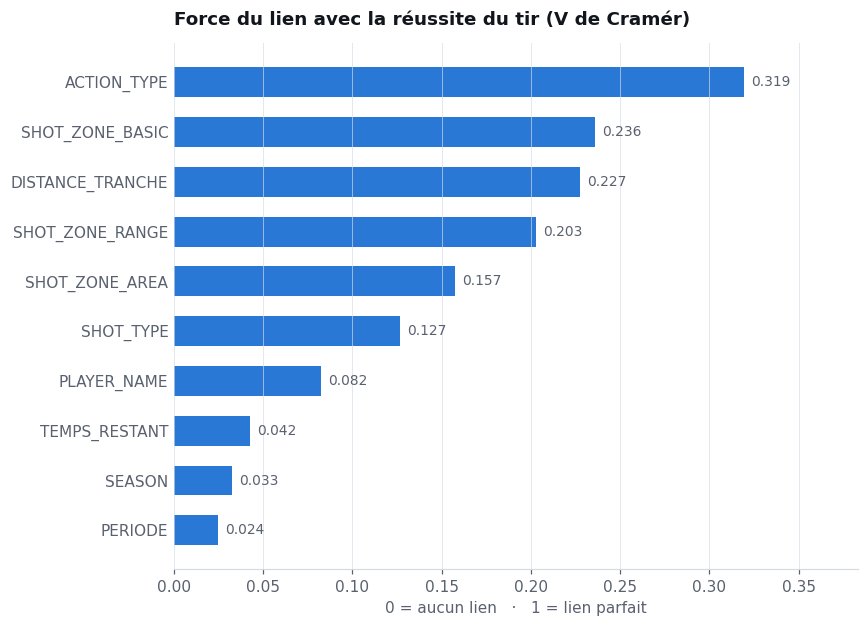

In [10]:
from scipy.stats import chi2_contingency

def cramers_v(a: pd.Series, b: pd.Series) -> float:
    """Association entre deux variables catégorielles, de 0 à 1 (correction de Bergsma)."""
    table = pd.crosstab(a, b)
    if table.shape[0] < 2 or table.shape[1] < 2:
        return np.nan
    chi2 = chi2_contingency(table, correction=False)[0]
    n = table.to_numpy().sum()
    phi2 = chi2 / n
    r, k = table.shape
    phi2corr = max(0, phi2 - (k - 1) * (r - 1) / (n - 1))
    rcorr = r - (r - 1) ** 2 / (n - 1)
    kcorr = k - (k - 1) ** 2 / (n - 1)
    denom = min(kcorr - 1, rcorr - 1)
    return np.sqrt(phi2corr / denom) if denom > 0 else np.nan


travail = tirs.copy()
# La distance est numérique : on la découpe en tranches pour la traiter comme
# les autres. Les bornes suivent la géométrie du terrain, pas des quantiles.
travail["DISTANCE_TRANCHE"] = pd.cut(
    travail["SHOT_DISTANCE"], [-1, 4, 10, 16, 23.75, 27, 100],
    labels=["0-4 ft", "4-10 ft", "10-16 ft", "16 ft-3pts", "3 pts", "longue distance"])
travail["PERIODE"] = travail["PERIOD"].clip(upper=5).astype(str)
travail["TEMPS_RESTANT"] = pd.cut(
    travail["MINUTES_REMAINING"], [-1, 0, 2, 6, 12],
    labels=["dernière minute", "1-2 min", "2-6 min", "6-12 min"])

VARIABLES = ["SHOT_ZONE_BASIC", "DISTANCE_TRANCHE", "ACTION_TYPE", "SHOT_TYPE",
             "SHOT_ZONE_AREA", "SHOT_ZONE_RANGE", "PLAYER_NAME", "PERIODE",
             "TEMPS_RESTANT", "SEASON"]

liens = (pd.Series({v: cramers_v(travail[v], travail["SHOT_MADE_FLAG"]) for v in VARIABLES})
           .dropna().sort_values())

fig, ax = plt.subplots(figsize=(8, 0.42 * len(liens) + 1.6))
ax.barh(liens.index, liens.values, color=BLEU, height=0.6)
for nom, v in liens.items():
    ax.text(v + 0.004, nom, f"{v:.3f}", va="center", fontsize=9, color=ENCRE_DOUX)
ax.set_title("Force du lien avec la réussite du tir (V de Cramér)")
ax.set_xlabel("0 = aucun lien   ·   1 = lien parfait")
ax.set_xlim(0, liens.max() * 1.2)
ax.grid(axis="y", visible=False)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)
plt.tight_layout()
plt.show()

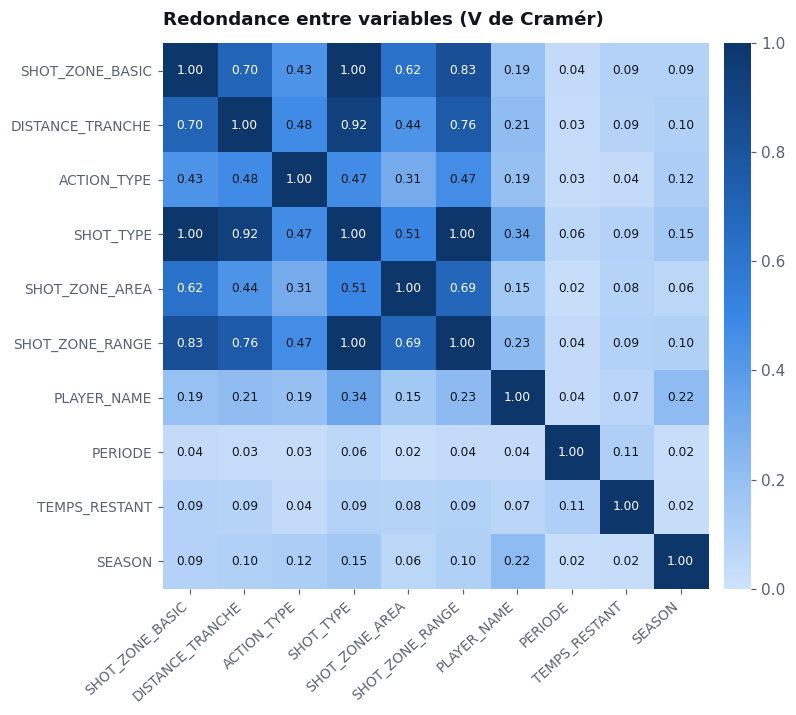

Paires très redondantes (V > 0.7), n'en garder qu'une :
  SHOT_ZONE_BASIC <-> DISTANCE_TRANCHE : 0.70
  SHOT_ZONE_BASIC <-> SHOT_TYPE : 1.00
  SHOT_ZONE_BASIC <-> SHOT_ZONE_RANGE : 0.83
  DISTANCE_TRANCHE <-> SHOT_TYPE : 0.92
  DISTANCE_TRANCHE <-> SHOT_ZONE_RANGE : 0.76
  SHOT_TYPE <-> SHOT_ZONE_RANGE : 1.00


In [11]:
# Redondance entre variables : deux variables très liées entre elles portent
# la même information. Deux dimensions -> carte de chaleur, teinte unique
# (la grandeur est une intensité, elle n'a pas de signe).
mat = pd.DataFrame(index=VARIABLES, columns=VARIABLES, dtype=float)
for i, a in enumerate(VARIABLES):
    for b in VARIABLES[i:]:
        v = 1.0 if a == b else cramers_v(travail[a], travail[b])
        mat.loc[a, b] = mat.loc[b, a] = v

fig, ax = plt.subplots(figsize=(8.2, 6.6))
im = ax.imshow(mat.values.astype(float), cmap=CMAP_SEQ, vmin=0, vmax=1)
ax.set_xticks(range(len(VARIABLES)), VARIABLES, rotation=42, ha="right", fontsize=9)
ax.set_yticks(range(len(VARIABLES)), VARIABLES, fontsize=9)
ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)

for i in range(len(VARIABLES)):
    for j in range(len(VARIABLES)):
        v = mat.iat[i, j]
        if pd.notna(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8,
                    color="white" if v > 0.55 else ENCRE)

ax.set_title("Redondance entre variables (V de Cramér)")
cb = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
cb.outline.set_visible(False)
plt.tight_layout()
plt.show()

print("Paires très redondantes (V > 0.7), n'en garder qu'une :")
vus = set()
for a in VARIABLES:
    for b in VARIABLES:
        if a != b and (b, a) not in vus and mat.loc[a, b] > 0.7:
            vus.add((a, b))
            print(f"  {a} <-> {b} : {mat.loc[a, b]:.2f}")

### Commentaire

Deux lectures à faire, et à retenir pour la réunion.

**Les valeurs sont faibles, et c'est normal.** Aucune variable ne dépasse un V modeste. Ce n'est
pas un défaut de l'extraction : c'est la mesure directe de ce que le sujet annonçait. Les
facteurs qui décident vraiment de l'issue d'un tir, pression du défenseur, contact, appuis,
fatigue, ne sont dans aucune de ces colonnes. **C'est le plafond de performance du futur
modèle, et on vient de le quantifier.** Un rapport qui l'établit dès l'exploration vaut mieux
qu'un rapport qui découvre en février que son AUC plafonne.

**Les variables de zone se répètent.** `SHOT_ZONE_BASIC`, `SHOT_ZONE_AREA`, `SHOT_ZONE_RANGE` et
la distance décrivent le même fait sous quatre formes. Les garder toutes ajouterait des colonnes
sans ajouter d'information. C'est un premier arbitrage concret pour l'étape 2.